# 00 - Raw duty sweep characterization

## Purpose

This notebook is the first in a series working toward an accurate,
mathematically proven servo control loop, built on empirical data. The
series starts from raw ADC readings and derives every quantity in the open.
Later notebooks compare these derivations against what the firmware
computes on the servo.

This notebook has three jobs:

1. Document the measurement chain and the constants that convert ADC
   readings into volts and amperes (section 2).
2. Measure the offset, noise, and limits of each raw channel (section 5).
3. Check that the data follows the expected brushed DC motor behavior
   (section 6).

The dataset is two capture campaigns with identical method, one powered
from a 2-cell lithium battery and one from a 5 V USB source, both on the
same servo and the same board. **The 2S campaign is the primary one and
every number, fit and coefficient below comes from it.** The USB campaign
appears only as a cross-check that a trend points the same way.

The reason is the rail. Across the duty range the USB rail droops a few
percent and it dips much further on spin-up, so a fit against duty on USB
folds rail droop into the duty axis and cannot tell the two apart. The 2S
rail is flat to a few tenths of a percent (section 6.2), so on 2S a fit
against duty is a fit against duty.

An earlier 2S campaign exists in the repository as `_retired-chain2`. It
was taken on the pre-bodge board, whose terminal taps returned to ground,
and no board entry describes it, so the loader refuses to open it. Nothing
below uses it.

## 1. Test setup

The device under test is an SG90-class hobby servo with its stock
electronics replaced by a custom controller board. Both campaigns ran on
that one board and that one servo, so nothing below compares measurement
chains: the only deliberate difference between the two campaigns is the
supply.

- A brushed DC motor driven by an H-bridge with 20 kHz PWM, center
  aligned. The controller commands **duty**. Duty is the fraction of each
  PWM period during which the bridge applies the supply across the motor.
  Duty is signed. Negative duty drives the opposite direction. For the
  rest of the period the bridge shorts the winding through its low-side
  switches (slow decay), the mode used throughout this dataset.
- A gear train couples the motor to the output shaft. A potentiometer on
  the output shaft is read by the MCU's 12-bit ADC. The pot wiper connects
  directly to an ADC pin, so position readings convert to volts at the
  wiper with no divider. Converting wiper volts to output angle needs the
  pot scale, which the servo registry carries as a disputed value (section
  2 prints it with its bracket), so position stays in wiper volts here.
- A shunt resistor in the motor return path, amplified and read by the
  ADC, gives the motor current channel. The recorded value is the
  amplifier output at the ADC pin, offset included.
- Both motor terminals are read through resistor dividers, channels
  `vmotor_a` and `vmotor_b`. The bottom leg of each divider returns to a
  bias node $V_B$ instead of ground, so a terminal that swings below
  ground keeps its ADC pin above ground and stays readable. Each tap has a
  reservoir capacitor, which is what lets the ADC's sample capacitor
  charge quickly from a divider of a few kOhm. Section 2 gives the tap
  formula and the board entry, and section 5.3 measures the bias.
- Each 50 us control period the ADC, clocked at 24 MHz, scans seven
  channels, triggered at the crest of the PWM counter, in the order shunt,
  `vmotor_a`, `vmotor_b`, position, a calibration reference, supply
  sense, and an NTC thermistor. The shunt uses a shorter sample aperture
  than the other channels. A second shunt sample at the trough of the
  counter gives `current_trough`.
- The controller streams every sample at the control rate (20,000 per
  second), packed 16 samples to a frame with a CRC. Corrupted frames are
  dropped and counted, so corruption turns into missing samples (verified
  in section 4). The wire budget at this rate allows six fields per
  sample. These recordings selected the six raw fields (position, both
  shunt samples, applied duty, both terminals). Supply sense and the NTC
  are streamable as `vbus_raw` and `ntc_raw` but were left out, so those
  two columns are empty and play no part in the analysis. The capture
  tool does read the supply-sense channel once per recording, at rest,
  and writes it into the metadata as `vbus_counts`; section 6.2 checks it
  against the rail seen at the motor.

**The board is a hacked rig.** The board under both campaigns is a
development board that has been reworked by hand several times (the shunt,
the dividers, the bias return, the reservoir capacitors, a repaired
amplifier pad). Its entry in the registry says so, and the note prints in
section 2. I know of one defect on it that the next board revision does
not have. The bus telemetry stream couples into the current amplifier's
output, so a shunt sample taken while a frame is going out on the wire can
read a few counts off. On the scan geometry of this firmware build it does
not show at rest (section 5.2 checks this by binning the rest current by
the sample's position inside the 16-sample frame), but it is a known
limitation of this board, and I do not code around it anywhere in this
notebook.

Power for the two campaigns, captured in separate sessions:

- **2S campaign (primary).** A 2-cell lithium battery, nominal 7.4 V,
  measured in section 6.2. This supply is above the 4.8 to 6 V range
  usually quoted for SG90-class servos, so the full-duty steps stress the
  mechanism beyond its usual rating. Its rail is flat across the duty
  range, which is why it is the primary campaign.
- **USB campaign (cross-check).** A laptop USB port. The voltage reaching
  the motor is measured in section 6.2. It is well below the nominal 5 V
  and drops further under load.

## 2. Constants and unit conversions

No constant is written into this notebook. The dataset's `manifest.json`
names a board and a servo; the board is the measurement chain (shunt,
amplifier, dividers, ADC, sample rate, drive-window floors) and the servo
is the mechanism (pot mapping, travel, the measured motor values). Both
live in `oscnb/boards.py` and `oscnb/servos.py`, and the cell below prints
everything they derive, so a reader on GitHub can check the numbers
without running anything.

The shunt, the divider legs, the amplifier gain and VDD are also written
into every recording's `meta.json` by the capture tool (the `sense`
block). Reading a recording checks that block against the board the
manifest names and raises on any disagreement, so a capture taken on
different parts fails at load rather than quietly producing numbers off by
the ratio of two shunts. The bias divider, the reservoir capacitor and the
sampling floors are not in the metadata, so the board entry is the only
record of them.

With the divider's bottom leg returned to the bias $V_B$, a terminal
voltage $V_t$ reaches the ADC pin as

$$\text{tap} = \frac{V_t}{r} + \frac{r - 1}{r} V_B, \qquad V_t = r\,\text{tap} - (r - 1)\, V_B, \qquad r = \frac{R_\text{top} + R_\text{bot}}{R_\text{bot}} .$$

With the bridge off and no current, both taps read $V_B$ exactly, which is
how the bias is measured per recording (section 5.3). Every absolute
terminal voltage below uses the second form with the measured $V_B$ of its
own terminal in its own recording, which is what `board.term_v` does. The
difference of the two terminals is bias-free when both dividers share the
one bias node, so that $v_A - v_B = r\,(\text{tap}_A - \text{tap}_B)$ in
ADC volts, which is `board.diff_v`.

Two caveats:

- The ADC reference is the chip's VDD supply. The figure in the board
  entry is the design value, and the actual VDD of this unit was not
  measured. Every voltage below scales linearly with the true VDD, so one
  future measurement of VDD rescales everything by one factor.
- The divider ratio, shunt and gain are design values. Component
  tolerances were not measured, and absolute voltages and currents carry
  them. The bias itself is measured, so it adds no tolerance of its own.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import oscnb

# The only constant this notebook owns: duty is encoded on the wire as a
# signed q15 fraction. Everything physical comes from the board and servo
# entries the dataset manifests name.
Q15 = 32767

DATASETS = {"2s": "sg90-a__dev-v006-D__2s", "usb": "sg90-a__dev-v006-D__usb"}
DS = {k: oscnb.datasets.load(v) for k, v in DATASETS.items()}

# 2S is primary: its rail is flat, so a fit against duty is a fit against
# duty. Selecting it prints the rig this notebook reports against.
ds = oscnb.use(DATASETS["2s"])
board, servo = oscnb.current().board, oscnb.current().servo

dataset  sg90-a__dev-v006-D__2s
supply   2s
rig      SG90 clone, unit A on osc-dev-v006 board D (bodged toward rev-2A)



,captures,recordings per capture,names
experiment,,,
breakaway,5,1,sweep
bridge,5,3,"fast, slow, spindown"
grid,10,1,sweep
reversal,5,1,sweep
ripple,5,1,sweep
stepcoast,5,5,"step120, step20, step40, step60, step80"



derived constants (what the hardware is)


value
where            quantity                                           unit                         
board            converter step                                     mV per count           0.8057
                 terminal divider ratio r                                                  3.0606
                 terminal difference                                mV per count           2.4658
                 terminal bias VB                                   mV                   627.9352
                                                                    counts               779.4008
                 driven-low terminal reads                          counts               524.7451
                 motor current                                      mA per count           0.8952
                                                                    counts per A        1117.0909
                 shunt                                              mOhm                  60.0000
                 amplifier gain                                     x                     15.0000
                 rail tap ratio                                                            2.5000
                 sample rate                                        samples per ms        20.0000
                 current settled from (UNVERIFIED)                  % duty                13.3333
                 voltage settled from (UNVERIFIED)                  % duty                13.3333
servo            pot intercept                                      counts               232.0000
                 pot slope                                          counts per degree     19.9600
                 envelope low                                       counts (10 deg)      431.6000
                 envelope high                                      counts (170 deg)    3625.2000
                 runway                                             counts              3193.6000
                 seek guard low                                     counts               432.0000
                 seek guard high                                    counts              3625.0000
servo (measured) gear_ratio_measured [234.73, 234.73] mechanical... :1                   234.7300
                 ripple_order_measured [6, 6] bringup isns-diff ... per motor rev          6.0000
                 kv_measured [7880, 8040] bringup isns-diff run28   RPM/V               7960.0000
                 kt_measured [1.19, 1.21] bringup isns-diff run28   mN-m/A                 1.2000
                 r_motor_measured [4.16, 4.24] bringup isns-diff... Ohm                    4.2000
                 l_motor_measured [0.45, 0.55] bringup isns-diff... mH                     0.5000
                 stall_current_measured [1.45, 1.55] bringup isn... A                      1.5000
                 stall_torque_measured [1.75, 1.85] bringup isns... mN-m                   1.8000
                 free_run_current_measured [0.078, 0.084] bringu... A                      0.0810
                 r_winding_measured [4.3, 4.8] nb03, full duty o... Ohm                    4.5000
                 pot_scale_measured [19.3, 19.43] nb06 sec 5.5, ... counts/deg            19.3000
                 coast_bemf_slope_measured [0.19, 0.204] nb01, c... V per wiper V/s        0.1970
                 ke_measured [7.44, 7.73] nb03 route R: ripple s... mV per motor rev/s     7.5840


measured values (what someone found when they looked)


value                 unit           bracket  \
where quantity                                                            
board vb_bias            781.000               counts        [775, 783]   
      rail_droop_usb      -3.500  % over 20-100% duty          [-4, -3]   
      opa_noise_floor      2.200           counts RMS          [2, 2.4]   
      esd_clamp_skew       1.800               V bemf        [1.7, 1.9]   
servo gear_ratio         234.730                   :1  [234.73, 234.73]   
      ripple_order         6.000        per motor rev            [6, 6]   
      kv                7960.000                RPM/V      [7880, 8040]   
      kt                   1.200               mN-m/A      [1.19, 1.21]   
      r_motor              4.200                  Ohm      [4.16, 4.24]   
      l_motor              0.500                   mH      [0.45, 0.55]   
      stall_current        1.500                    A      [1.45, 1.55]   
      stall_torque         1.800                 mN-m      [1.75, 1.85]   
      free_run_current     0.081                    A    [0.078, 0.084]   
      r_winding            4.500                  Ohm        [4.3, 4.8]   
      pot_scale           19.300           counts/deg     [19.3, 19.43]   
      coast_bemf_slope     0.197      V per wiper V/s     [0.19, 0.204]   
      ke                   7.584   mV per motor rev/s      [7.44, 7.73]   

                                                                   source  \
where quantity                                                              
board vb_bias                     Hi-Z rest baseline, 2S grid + stepcoast   
      rail_droop_usb                      2S vs USB grid, 5 captures each   
      opa_noise_floor                             bringup isns-diff run29   
      esd_clamp_skew                           bringup isns-diff findings   
servo gear_ratio                          mechanical/sg90/measurements.py   
      ripple_order                           bringup isns-diff runs 25-27   
      kv                                          bringup isns-diff run28   
      kt                                          bringup isns-diff run28   
      r_motor                                     bringup isns-diff run28   
      l_motor                                     bringup isns-diff run28   
      stall_current                               bringup isns-diff run28   
      stall_torque                                bringup isns-diff run28   
      free_run_current                            bringup isns-diff run28   
      r_winding                              nb03, full duty onset anchor   
      pot_scale         nb06 sec 5.5, travel-weighted ripple cycle cou...   
      coast_bemf_slope                                      nb01, chain 2   
      ke                nb03 route R: ripple speed + coast BEMF over 2...   

                                                                   caveat  
where quantity                                                             
board vb_bias           nominal 779 from the 200/47 network, so 0.3%. ...  
      rail_droop_usb    USB also dips -21.8% transiently at 0.76 A; 2S...  
      opa_noise_floor   arm-B external network at G15; the internal PG...  
      esd_clamp_skew    above this the A-side ESD clamp skews the divi...  
servo gear_ratio        (47*38*32*23)/(10*10*8*7), counted teeth on th...  
      ripple_order      3-segment commutator x 2 brushes; optical tach...  
      kv                bare can, +/-1% HSI scale; pinion stayed on th...  
      kt                                                                   
      r_motor           bare can. nb03 got 4.5 [4.3, 4.8] in-servo via...  
      l_motor                            locked-rotor burst, tau_e 102 us  
      stall_current                                       = V/R confirmed  
      stall_torque                                                         
      free_run_current                                         at duty 65

## 3. Capture method

The recordings live in the repository under `notebooks/telemetry/`, one
folder per dataset, one subfolder per experiment. This notebook reads the
`grid` experiment of both datasets, whose captures are named
`capture-N`. One capture contains 41 segments, captured back to back:

- **Segment 0** is a one-second baseline with the motor undriven. It
  measures the noise floor of each channel, the current amplifier's
  offset, and the terminal bias.
- **Segments 1 to 40** are constant-duty drive steps, duty from 5% to 100%
  in 5% increments, first forward then reverse. Before each step the servo
  is repositioned at 15% duty toward the far end of travel, so there is
  room to accelerate.

The drive window is **not** a fixed 80 ms any more. Each rung's window is
sized from that supply's own steady-speed fit so that every rung travels
roughly the same distance, about 2554 pot counts, inside the 10 to 170
degree envelope. The schedule prints in each capture's metadata as
`duty@milliseconds`. On 2S the windows run from 1500 ms at 5% duty down to
124 ms at 100%; on USB, where the motor is slower, the same travel needs
1500 ms down to 197 ms. This matters for two reasons: the low rungs get
enough time to show whether they move at all, and the fast rungs stop
before they run out of runway.

Between captures the servo was rebooted and rested, and one warm-up
capture per experiment was discarded, so every capture starts from the
same software state and a similar thermal state. Both campaigns follow this
method exactly. The differences are the supply, the session, and the
window schedule that the supply implies.

**Braking between steps.** After each step's capture window closes, the
sweep tool commands a brief slow-decay brake, which short-circuits the
motor winding and brings the motor to rest. The braking happens after the
capture window, so the recorded data is unaffected.

**Data acceptance.** Any capture in which the host counted even one
dropped frame was discarded and re-run. Section 4 re-verifies this from
the data itself.

Each row of a capture is one 50 us sample, holding the segment number,
commanded duty, direction, tick counter, the firmware's sampling-validity
flag (section 5.4), the raw channels (position, crest and trough shunt
samples, applied duty, both motor terminals), and the empty columns for
supply sense and the NTC. The loader attaches to every capture its
baseline constants, the current offset (mean of `current_raw` over segment
0) and the terminal bias $V_B$ of each terminal (median of `vmotor_a` and
of `vmotor_b` over segment 0).

In [2]:
# Only the streamed columns are kept, as int32: the USB grid alone is ten
# million samples and the full-width float frame does not need to exist.
KEEP = ["seg", "cmd_duty_q15", "dir", "tick", "window_valid", "pos",
        "current_raw", "current_trough", "vmotor_a", "vmotor_b"]

def load_recording(rec):
    # rec.frame() checks the recording's own `sense` block against the board
    # the manifest names and raises on a mismatch. Derived columns: duty_pct
    # (signed percent), t_ms (ms since start), and the per-recording baseline
    # constants bias, vb (terminal A) and vb_b (terminal B).
    df = rec.frame()[KEEP].astype("int32")
    df["duty_pct"] = (df["cmd_duty_q15"] * (100.0 / Q15)).astype("float32")
    df["t_ms"] = ((df["tick"] - df["tick"].iloc[0])
                  / (board.tick_hz / 1000)).astype("float32")
    base = df[df["seg"] == 0]
    df["bias"] = np.float32(base["current_raw"].mean())
    df["vb"] = np.float32(base["vmotor_a"].median())
    df["vb_b"] = np.float32(base["vmotor_b"].median())
    return df, rec.meta

def load_series(key):
    d = DS[key]
    return {cap: load_recording(d.recordings("grid", cap)[0])
            for cap in d.captures("grid")}

# Every loop below walks this list. 2S first, and first is primary.
SERIES = [(k, load_series(k)) for k in ("2s", "usb")]
COLORS = {"2s": "tab:blue", "usb": "tab:orange"}

pd.DataFrame({"captures": [len(recs) for _, recs in SERIES],
              "samples": [sum(len(df) for df, _ in recs.values()) for _, recs in SERIES],
              "role": ["primary", "cross-check"]},
             index=[label for label, _ in SERIES])

,captures,samples,role
2s,10,3368000,primary
usb,20,9672800,cross-check


## 4. Data integrity

The transport turns a corrupted frame into a missing sample. One frame
carries 16 consecutive samples, so a dropped frame appears as a 16-tick
jump in the tick column. The table below recomputes the missing-sample
count for every capture from the tick column.

In [3]:
def integrity(recs):
    rows = []
    for name, (df, meta) in recs.items():
        missing = 0
        for _, seg in df.groupby("seg"):
            ticks = seg["tick"].to_numpy()
            missing += int(ticks[-1] - ticks[0] + 1 - len(ticks))
        rows.append({
            "capture": name,
            "samples": len(df),
            "segments": df["seg"].nunique(),
            "missing_samples": missing,
        })
    return pd.DataFrame(rows)

integ = pd.concat([integrity(recs).assign(series=label) for label, recs in SERIES],
                  ignore_index=True)
integ.groupby("series").agg(captures=("capture", "count"),
                            segments=("segments", "max"),
                            samples_min=("samples", "min"),
                            samples_max=("samples", "max"),
                            missing_samples=("missing_samples", "sum"))

,captures,segments,samples_min,samples_max,missing_samples
series,,,,,
2s,10,41,336800,336800,0
usb,20,41,483640,483640,0


Every capture holds 41 segments with zero missing samples. The sample
counts differ between the two campaigns, and within a campaign they do
not, because the window schedule is per supply and fixed inside a
campaign.

## 5. Channel characterization

### 5.1 Position

The position channel is the pot wiper voltage. The baseline segment of
each capture gives its noise floor at rest. The repositioning move before
the baseline ends with the motor unpowered, and the mechanism can still be
coasting to rest when the capture starts. The code below measures this
residual motion two ways, as the offset of the first 100 ms from the
settled level and as the time of the last sample outside the settled noise
band. The noise statistics drop the first 200 ms of the one-second
baseline and use the settled remainder.

In [4]:
rows = []
for series, recs in SERIES:
    for name, (df, _) in recs.items():
        base = df[df["seg"] == 0]["pos"].to_numpy() * board.v_adc_per_count
        settled = base[len(base) // 5:]
        med = np.median(settled)
        band = np.max(np.abs(settled - med))
        outside = np.where(np.abs(base - med) > band)[0]
        rows.append({
            "series": series,
            "peak_dev_mV": band * 1e3,
            "std_mV": np.std(settled) * 1e3,
            # residual coast from the repositioning move: how far the
            # first 100 ms sits from the settled level, and when the
            # trace last leaves the settled band
            "coast_first_100ms_mV": abs(np.median(base[:2000]) - med) * 1e3,
            "coast_settle_ms": (outside[-1] + 1) / (board.tick_hz / 1000) if len(outside) else 0.0,
        })
pd.DataFrame(rows).groupby("series").agg(["mean", "max"]).round(2)

peak_dev_mV       std_mV       coast_first_100ms_mV        \
              mean   max   mean   max                 mean   max   
series                                                             
2s            3.38  4.03   0.97  1.19                 1.85  2.42   
usb           3.26  4.83   1.01  1.73                 1.09  3.22   

       coast_settle_ms         
                  mean    max  
series                         
2s               46.27   51.5  
usb              45.75  165.6

On the 2S campaign the rest noise has a standard deviation of about 1.0 mV
and a peak deviation under 4.1 mV at the wiper (one ADC count is 0.81 mV,
so the peak deviation is five counts). USB agrees: 1.0 mV standard
deviation and under 4.9 mV peak. The channel does not go through anything
the supply touches, so agreement here is expected and is a check on the
two sessions rather than on the supply.

The mechanism is at rest within about 46 ms on average on both campaigns,
inside the 200 ms trimmed from every baseline, with one USB capture taking
166 ms. Section 6.1 uses the peak deviation as the bound for deciding
whether a drive step produced real motion.

### 5.2 Current offset

The bridge is disabled during the baseline, so no current flows through
the shunt and the baseline reading is the amplifier's output offset. It is
measured below from every baseline segment of both campaigns, with the
rest noise of the channel next to it. The second table is the board caveat
from section 1. It bins the rest current by the sample's position inside
the 16-sample telemetry frame. If the bus stream were reaching the shunt
samples at rest, some positions would read higher than others.

In [5]:
rows = []
for label, recs in SERIES:
    offs = np.array([df["bias"].iloc[0] for df, _ in recs.values()])
    # rest noise: std of the settled baseline (first 200 ms dropped), per capture
    noise = np.array([df[df["seg"] == 0]["current_raw"].to_numpy()[4000:].std()
                      for df, _ in recs.values()])
    off_v = offs.mean() * board.v_adc_per_count
    rows.append({
        "series": label,
        "offset_counts": offs.mean(),
        "offset_counts_min": offs.min(),
        "offset_counts_max": offs.max(),
        "offset_mV": off_v * 1e3,
        "offset_mA_equivalent": off_v / (board.amp_gain * board.shunt_ohm) * 1e3,
        "capture_spread_mV": offs.std() * board.v_adc_per_count * 1e3,
        "rest_noise_std_counts": noise.mean(),
        "rest_noise_std_mA": noise.mean() * board.a_per_count * 1e3,
    })
display(pd.DataFrame(rows).set_index("series").round(2))

# Board caveat check: rest current by position inside the 16-sample frame.
# Position = tick mod 16.
rows = []
for label, recs in SERIES:
    phase = pd.concat([df[df["seg"] == 0].assign(frame_pos=lambda d: d["tick"] % 16)
                       for df, _ in recs.values()])
    by_pos = phase.groupby("frame_pos")[["current_raw", "current_trough"]].mean()
    spread = by_pos.max() - by_pos.min()
    rows.append({"series": label,
                 "samples_per_bin": len(phase) // 16,
                 "crest_spread_counts": spread["current_raw"],
                 "trough_spread_counts": spread["current_trough"],
                 "crest_spread_mA": spread["current_raw"] * board.a_per_count * 1e3})
pd.DataFrame(rows).set_index("series").round(2)

,offset_counts,offset_counts_min,offset_counts_max,offset_mV,offset_mA_equivalent,capture_spread_mV,rest_noise_std_counts,rest_noise_std_mA
series,,,,,,,,
2s,102.669998,100.580002,105.889999,82.720001,91.910004,1.4,1.03,0.92
usb,108.239998,106.629997,110.029999,87.199997,96.889999,0.7,1.32,1.18


,samples_per_bin,crest_spread_counts,trough_spread_counts,crest_spread_mA
series,,,,
2s,12500,0.62,0.82,0.55
usb,25000,0.73,0.85,0.65


Within a campaign the offset is stable to under 1.5 mV across
reboot-separated captures. The 2S session reads 100.6 to 105.9 counts and
the USB session 106.6 to 110.0, so the two sessions differ by about 5.6
counts (4.5 mV) in the mean. The offset is large in both, worth about 92
to 97 mA equivalent through the shunt, so it must be subtracted before
current readings mean anything. Later notebooks subtract the per-capture
baseline value. The rest noise is about 1.0 counts standard deviation on
2S and 1.3 on USB, roughly 1 mA. *Hypothesis (not tested here): the
session difference tracks the board's supply or temperature, since the
amplifier sits on the same 3V3 the ADC references. Testing it requires
baselines on both supplies within one session.*

The frame-position table is flat. Across the sixteen positions the crest
sample spans 0.6 counts on 2S and 0.7 on USB, and the trough sample 0.8
counts on both, against a per-sample noise of 1.0 to 1.3 counts. Each bin
pools at least 12,500 samples, so the spread is real, but it is under
1 mA and well under the noise, which is what I meant by invisible at rest.
It stays on the list as a board limitation.

### 5.3 Terminal bias

With the bridge off and no current in the winding, both terminal dividers
sit at the bias node, so the baseline reads $V_B$ directly on both
channels. The median over the full one-second baseline is robust against
the coasting motor's back-EMF in the first tens of milliseconds. The table
compares the two channels and the nominal value per campaign.

In [6]:
rows = []
for label, recs in SERIES:
    vb = np.array([df["vb"].iloc[0] for df, _ in recs.values()])
    vb_b = np.array([df["vb_b"].iloc[0] for df, _ in recs.values()])
    rows.append({
        "series": label,
        "VB_A_counts_min": vb.min(),
        "VB_A_counts_max": vb.max(),
        "VB_A_mV": vb.mean() * board.v_adc_per_count * 1e3,
        "VB_B_counts_min": vb_b.min(),
        "VB_B_counts_max": vb_b.max(),
        "VB_B_mV": vb_b.mean() * board.v_adc_per_count * 1e3,
        "B_minus_A_counts_min": (vb_b - vb).min(),
        "B_minus_A_counts_max": (vb_b - vb).max(),
        "VB_nominal_counts": board.vb_nom_counts,
        "VB_nominal_mV": board.vb_nom_v * 1e3,
        "VB_A_minus_nominal_mV": (vb.mean() * board.v_adc_per_count - board.vb_nom_v) * 1e3,
        "VB_B_minus_nominal_mV": (vb_b.mean() * board.v_adc_per_count - board.vb_nom_v) * 1e3,
    })
pd.DataFrame(rows).set_index("series").round(2).T

series,2s,usb
VB_A_counts_min,778.000000,778.000000
VB_A_counts_max,778.000000,779.000000
VB_A_mV,626.809998,626.849976
VB_B_counts_min,782.000000,782.000000
VB_B_counts_max,782.000000,782.000000
VB_B_mV,630.030029,630.030029
B_minus_A_counts_min,4.000000,3.000000
B_minus_A_counts_max,4.000000,4.000000
VB_nominal_counts,779.400000,779.400000
VB_nominal_mV,627.940000,627.940000


Both taps sit within a few counts of the 779.4-count nominal in both
campaigns and in every capture: `vmotor_a` reads 778 (0.627 V, 1.1 mV
below nominal) and `vmotor_b` reads 782 (0.630 V, 2.1 mV above), a
four-count split that is the same on 2S and on USB and moves by at most
one count across captures. The registry's measured bias of 781 counts
[775, 783] covers both.

The split is small but it is not zero, and with the bridge off the winding
ties the two terminals together, so both dividers return to the one bias
node and the two taps ought to read the same. Four counts is 3.2 mV at the
pin. Two things could produce it: a real potential difference from bridge
leakage through the dividers, or residual ADC settling, since `vmotor_a`
is scanned right after the shunt channel and `vmotor_b` right after
`vmotor_a`. Section 9 says what would separate them. Either way it is
stable, so every absolute terminal voltage below uses the terminal's own
rest reading as its $V_B$, which absorbs the split as an offset. A
one-count uncertainty in $V_B$ enters an absolute terminal voltage
multiplied by $r - 1$, about 1.6 mV, and is left uncorrected.

### 5.4 Sampling floors and the validity flag

The scan is triggered at the crest of the PWM counter, which under slow
decay is the center of the drive window. The crest sample therefore sits
inside the drive window at every nonzero duty. Whether it is settled
depends on how far the window's edge is from the scan. The board entry
states one floor for current and one for voltage, both printed in section
2 as a duty percentage, and it marks them UNVERIFIED: three different
values for the voltage floor appear in different places in the firmware
tree, and the flashed build was not checked. The firmware stamps every
sample with a validity flag that encodes the current floor. The figure
below shows the driven terminal's raw samples at three duty levels on a 2S
capture, then the table checks where the recorded flag flips.

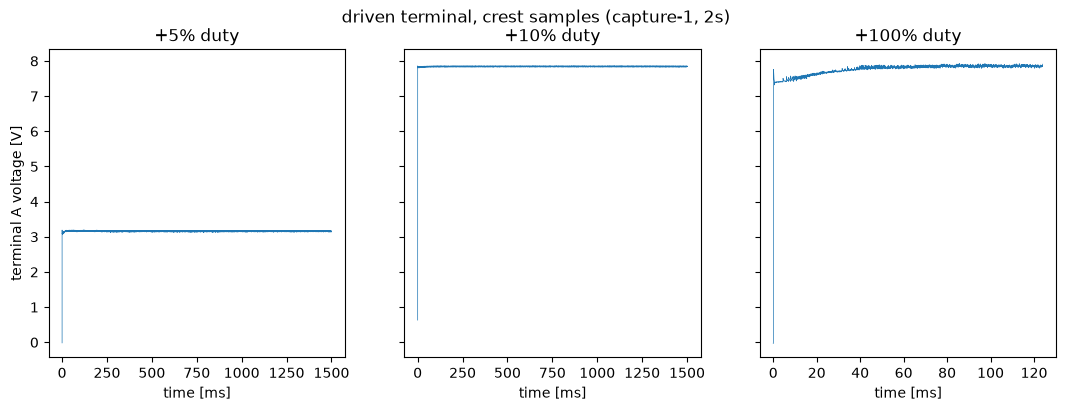

,captures,distinct_flip_points,invalid_up_to_pct,valid_from_pct,configured_current_floor_pct
series,,,,,
2s,10,1,10.0,15.0,13.33
usb,20,1,10.0,15.0,13.33


In [7]:
name, (df, meta) = next(iter(SERIES[0][1].items()))
vb = df["vb"].iloc[0]
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, pct in zip(axes, [5, 10, 100]):
    seg = df[np.isclose(df["duty_pct"], pct, atol=0.5)]
    t = (seg["tick"] - seg["tick"].iloc[0]) / (board.tick_hz / 1000)
    ax.plot(t, board.term_v(seg["vmotor_a"], vb), lw=0.5)
    ax.set_title(f"+{pct}% duty")
    ax.set_xlabel("time [ms]")
axes[0].set_ylabel("terminal A voltage [V]")
fig.suptitle(f"driven terminal, crest samples ({name}, 2s)")
plt.show()

# Where does the recorded validity flag flip? Checked in every capture of
# both campaigns.
rows = []
for label, recs in SERIES:
    flips = set()
    for df, _ in recs.values():
        v = df[df["seg"] > 0].groupby("seg").agg(
            d=("duty_pct", "first"), valid_frac=("window_valid", "mean"))
        v["mag"] = v["d"].abs().round()
        flips.add((v[v.valid_frac <= 0.5]["mag"].max(),
                   v[v.valid_frac > 0.5]["mag"].min()))
    rows.append({
        "series": label,
        "captures": len(recs),
        "distinct_flip_points": len(flips),
        "invalid_up_to_pct": max(h for h, _ in flips),
        "valid_from_pct": min(l for _, l in flips),
        "configured_current_floor_pct": board.floor_i_pct,
    })
pd.DataFrame(rows).set_index("series").round(2)

At +100% duty the crest sample reads the rail in every period, after a dip
in the first few milliseconds while the rail sags under the inrush and
recovers. At +10% it reads the rail from the first period. At +5% it reads
about 3.1 V against a 7.65 V rail, less than half, because the drive
window's edge is 60 ticks from the scan and the divider has not settled.
The motor still receives its share of the supply during that step, and the
position data in section 6.1 shows what it does with it.

The recorded flag flips between the 10% and 15% duty steps in every
capture of both campaigns, which is the single flip point the 13.3%
current floor implies on this 5% grid.

The two terminals settle at different duty. The table below pools the
driven terminal's median reading per step across all captures, terminal A
for forward steps and terminal B for reverse, each bias-corrected with its
own rest reading.

In [8]:
rows = []
for label, recs in SERIES:
    for df, _ in recs.values():
        vb_a, vb_b = df["vb"].iloc[0], df["vb_b"].iloc[0]
        for seg_id, seg in df.groupby("seg"):
            d = seg["duty_pct"].iloc[0]
            mag = int(round(abs(d)))
            if seg_id == 0 or mag > 25:
                continue
            term, vbx = (seg["vmotor_a"], vb_a) if d > 0 else (seg["vmotor_b"], vb_b)
            rows.append({
                "series": label,
                "terminal": "A (forward)" if d > 0 else "B (reverse)",
                "duty_mag_pct": mag,
                "driven_V": board.term_v(term.median(), vbx),
            })
(pd.DataFrame(rows)
   .groupby(["duty_mag_pct", "series", "terminal"])["driven_V"].mean()
   .unstack(["series", "terminal"]).round(2))

series                2s                     usb            
terminal     A (forward) B (reverse) A (forward) B (reverse)
duty_mag_pct                                                
5                   3.14        0.13        1.72        0.07
10                  7.79        5.20        4.66        2.97
15                  7.79        7.73        4.65        4.62
20                  7.79        7.73        4.64        4.61
25                  7.79        7.73        4.63        4.60

This settles the voltage floor from data. On 2S terminal A reads the full
7.79 V rail from the 10% step, but terminal B reads 5.20 V there against
7.73 V from 15% up, so terminal B's window edge lies between 10% and 15%
duty. USB shows the same shape: A settled from 10% at 4.66 V, B at 2.97 V
at 10% and 4.62 V from 15%. The configured floor of 13.3% (160 timer
ticks) is the only one of the three candidates that covers both terminals:
a 120-tick floor would pass terminal B samples at the 10% step that are
30% low. The floor stays marked unverified in the registry because that is
a statement about the flashed firmware, not about this data, but this data
is consistent with 160 ticks and rules out 120.

This imposes two rules on everything below:

- Current readings and terminal voltage readings are used only where the
  validity flag is set, which on this grid means the 15% step and up, and
  additionally at or above the configured voltage floor.
- Below those floors the position channel is the only trusted channel.
  The pot wiper is sampled directly, outside the PWM window, so position
  has no such limit.

## 6. Results

### 6.1 Motion threshold

For each drive step, net travel is the difference between the median of
the last 20 and the first 20 position samples (medians so a single noise
spike cannot fake motion). This is compared against the rest-noise band
from section 5.1. One complication needs handling. Each drive step begins
shortly after a repositioning move, and the mechanism can still be
coasting from that move when the step begins (section 5.1 measures this in
the baselines). Drive-produced motion follows the commanded direction.
Residual coast follows the repositioning move, which by construction of
the test runs opposite the drive direction. So besides the per-step
scatter, the table pools travel aligned with the drive direction across
all captures.

Because the windows are sized for equal travel, the plateau at the right
of each panel is the design of the schedule and not a fact about the
motor. The left end, where the schedule gives the low rungs 1500 ms, is
the part that carries information.

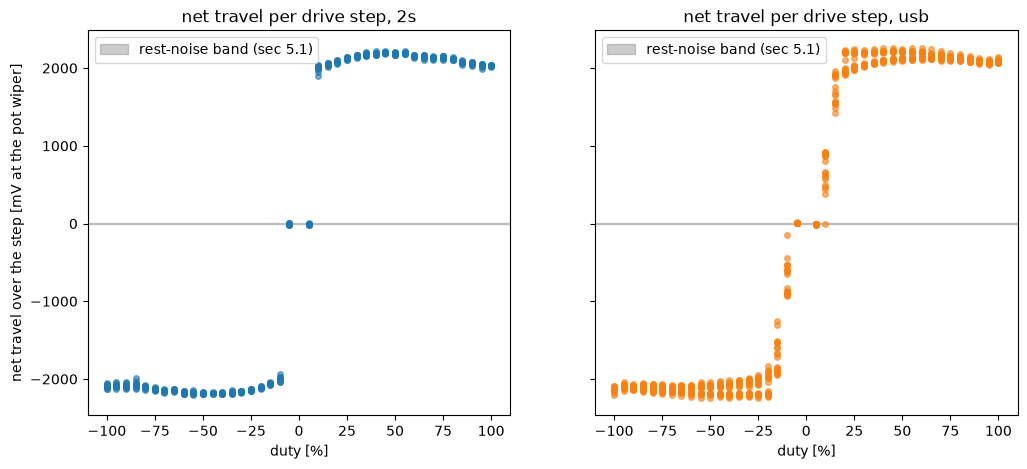

2s                         usb                     
                mean   std     min count    mean    std     min count
duty_mag_pct                                                         
5.0             -1.0  11.2   -18.5    20    -7.9    3.7   -17.7    40
10.0          1994.1  36.7  1894.9    20   699.1  228.4     0.0    40
15.0          2053.0  16.2  2015.0    20  1725.9  194.9  1259.7    40
20.0          2096.0  18.4  2056.9    20  2072.8  132.1  1832.1    40

,rest-noise band [mV]
2s,4.03
usb,4.83


In [9]:
def step_travel(df):
    out = []
    for seg_id, seg in df.groupby("seg"):
        if seg_id == 0:
            continue
        p = seg["pos"].to_numpy() * board.v_adc_per_count * 1e3   # mV at the wiper
        out.append({
            "duty_pct": seg["duty_pct"].iloc[0],
            "travel_mV": np.median(p[-20:]) - np.median(p[:20]),
        })
    return pd.DataFrame(out)

def rest_band_mV(df):
    base = df[df["seg"] == 0]["pos"].to_numpy() * board.v_adc_per_count * 1e3
    settled = base[len(base) // 5:]
    return np.max(np.abs(settled - np.median(settled)))

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
bands = {}
for ax, (title, recs) in zip(axes, SERIES):
    band = 0.0
    for name, (df, meta) in recs.items():
        tr = step_travel(df)
        band = max(band, rest_band_mV(df))
        ax.plot(tr["duty_pct"], tr["travel_mV"], "o", ms=4, alpha=0.6,
                color=COLORS[title])
    bands[title] = band
    ax.axhspan(-band, band, color="grey", alpha=0.4,
               label="rest-noise band (sec 5.1)")
    ax.set_xlabel("duty [%]")
    ax.set_title(f"net travel per drive step, {title}")
    ax.legend(loc="upper left")
axes[0].set_ylabel("net travel over the step [mV at the pot wiper]")
plt.show()

# Drive-aligned travel by |duty| in mV; positive = moved in the
# commanded direction.
tables = {}
for label, recs in SERIES:
    allt = pd.concat([step_travel(df) for df, _ in recs.values()])
    allt["aligned_mV"] = allt["travel_mV"] * np.sign(allt["duty_pct"])
    tables[label] = (allt.assign(duty_mag_pct=np.abs(allt["duty_pct"]).round())
                         .groupby("duty_mag_pct")["aligned_mV"]
                         .agg(["mean", "std", "min", "count"]).head(4))
aligned = pd.concat(tables, axis=1)
display(aligned.round(1))
pd.Series(bands, name="rest-noise band [mV]").round(2).to_frame()

Findings:

- At 10% duty the servo moves. On 2S the mean aligned travel is 1994 mV
  over the 1500 ms window and the smallest of the twenty steps is 1895 mV,
  clearing the 4.0 mV rest-noise band by nearly three orders of magnitude.
  USB agrees in direction and disagrees in margin: its mean is 699 mV with
  a standard deviation of 228 mV and a minimum of exactly zero, so some
  10% steps on USB do not break away at all. That is the same threshold
  seen from the other side, and section 9 keeps it.
- At 5% duty the aligned travel is within a few millivolts of zero on 2S
  (mean -1.0 mV against a 4.0 mV band) and slightly negative on USB (mean
  -7.9 mV, spread 3.7). Drive cannot produce motion opposite the command.
  Residual coast can, and its direction opposes the drive direction here by
  construction. The 5% steps are therefore consistent with zero
  drive-produced motion on both supplies.

So the motion threshold of this unit lies between 5% and 10% duty on both
supplies. Section 6.2 converts this duty bracket into a voltage bracket
once the rail is measured.

### 6.2 Supply voltage under load

These recordings carry no per-sample supply-sense channel (section 1).
They have the two motor terminals. While the bridge drives, the driven
terminal connects to the supply through the high-side switch, so its
voltage is the supply minus the switch drop. The estimate below takes, per
drive step, the 90th percentile of the driven terminal's valid samples
(terminal A when driving forward, terminal B in reverse), bias-corrected
with that terminal's own $V_B$ from the capture and restricted to duty at
or above the configured voltage floor. Steps below the floor have no valid
voltage samples and are absent from the figure. The table also reports the
partner terminal at full duty, which the low-side switch holds near
ground, as a check on the bias correction, and the once-per-capture
supply-sense reading from the metadata converted through the board's rail
tap.

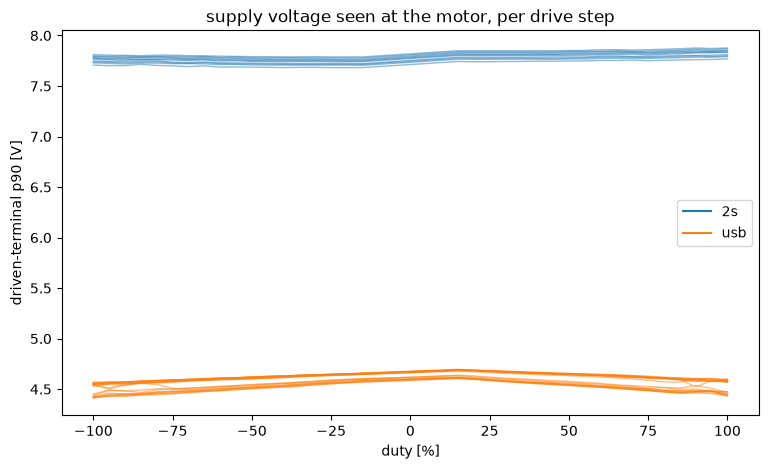

,light_load_V,full_duty_V,droop_20_to_100_pct,low_side_full_duty_V,vsense_rest_V,vsense_over_terminal
series,,,,,,
2s,7.771,7.793,0.290,0.131,6.383,0.821
usb,4.629,4.519,-2.452,0.070,3.811,0.823


registry rail droop on USB: -3.5 % over 20-100% duty [-4, -3] (2S vs USB grid, 5 captures each) - USB also dips -21.8% transiently at 0.76 A; 2S is flat (+0.1%) and dips only -5.9% at 1.70 A. ~1.3 ohm vs ~0.27 ohm source Z


In [10]:
def step_supply(df):
    # Supply estimate per drive step: p90 of the driven terminal, valid
    # samples at or above the voltage floor only. low_side_V is the
    # median of the partner terminal over the same samples. Each terminal
    # is bias-corrected with its own rest reading.
    vb_a, vb_b = df["vb"].iloc[0], df["vb_b"].iloc[0]
    out = []
    for seg_id, seg in df.groupby("seg"):
        if seg_id == 0:
            continue
        d = seg["duty_pct"].iloc[0]
        if abs(d) < board.floor_v_pct:
            continue
        v = seg[seg["window_valid"] == 1]
        if len(v) < 100:
            continue
        if d > 0:
            hi, lo, vbh, vbl = v["vmotor_a"], v["vmotor_b"], vb_a, vb_b
        else:
            hi, lo, vbh, vbl = v["vmotor_b"], v["vmotor_a"], vb_b, vb_a
        out.append({"duty_pct": d,
                    "supply_V": board.term_v(hi.quantile(0.9), vbh),
                    "low_side_V": board.term_v(lo.median(), vbl)})
    return pd.DataFrame(out).sort_values("duty_pct")

SUPPLY = {label: {name: step_supply(df) for name, (df, _) in recs.items()}
          for label, recs in SERIES}

fig, ax = plt.subplots(figsize=(9, 5))
for label, recs in SERIES:
    for name in recs:
        r = SUPPLY[label][name]
        ax.plot(r["duty_pct"], r["supply_V"], "-", lw=1, alpha=0.5, color=COLORS[label])
    ax.plot([], [], "-", color=COLORS[label], label=label)
ax.set_xlabel("duty [%]")
ax.set_ylabel("driven-terminal p90 [V]")
ax.set_title("supply voltage seen at the motor, per drive step")
ax.legend()
plt.show()

rows = []
for label, recs in SERIES:
    hi, lo, ls, d20 = [], [], [], []
    for name, (df, meta) in recs.items():
        r = SUPPLY[label][name]
        mag = r["duty_pct"].abs().round()
        full = r[mag >= 95]
        lo.append(full["supply_V"].mean())
        ls.append(full["low_side_V"].mean())
        hi.append(r[mag <= 30]["supply_V"].mean())
        d20.append(r[mag == 20]["supply_V"].mean())
    meta = next(iter(recs.values()))[1]
    rows.append({
        "series": label,
        "light_load_V": np.mean(hi),
        "full_duty_V": np.mean(lo),
        "droop_20_to_100_pct": (np.mean(lo) / np.mean(d20) - 1) * 100,
        "low_side_full_duty_V": np.mean(ls),
        "vsense_rest_V": board.vsys_v(meta["vbus_counts"]),
        "vsense_over_terminal": board.vsys_v(meta["vbus_counts"]) / np.mean(hi),
    })
supply = pd.DataFrame(rows).set_index("series")
display(supply.round(3))
print("registry rail droop on USB:", board.measured["rail_droop_usb_measured"])

Findings:

- **The 2S rail is flat.** It delivers 7.77 V at light load and 7.79 V at
  full duty, and from the 20% rung to the 100% rung it changes by +0.3%. That is
  why every fit in this notebook is on 2S: on this rail, duty times supply
  and duty differ by a constant.
- **The USB rail is not.** It delivers 4.63 V at light load, already well
  below the nominal 5 V, and 4.52 V at full duty, a droop of -2.5% over
  the same range. The registry carries this as
  `rail_droop_usb_measured` = -3.5% [-4.0, -3.0] from the same campaign;
  the driven-terminal p90 used here reads -2.5%, half a point outside
  that bracket, and section 9 keeps the gap. Either way the sign and
  the order of magnitude are the same, and the first few milliseconds of
  every high-duty step dip much lower than the p90 shows (the +100% panel
  of section 5.4). *Hypothesis (not tested here): the standing deficit and
  the load dependence are resistive and diode drops in the cable,
  connectors, and the board's input path. Testing it requires measuring
  the voltage at the port and at the board input at the same time.*
- The low-side terminal reads 0.131 V (2S) and 0.070 V (USB) at full duty
  after the bias correction, the drop across the conducting low-side
  switch and the shunt. Without the correction it would read
  $(r - 1) V_B$ higher, about 1.29 V.
- **The once-per-capture supply-sense reading does not agree with the
  motor rail.** Through the board's declared rail tap it comes out at
  6.38 V on 2S and 3.81 V on USB, 18% below the terminal p90 on both. It
  cannot be right: the driven terminal is fed from that same rail through
  the high-side switch, so it can only read *below* the rail, never above.
  Section 9 has the candidate causes and the measurement that separates
  them. Nothing below uses `vbus_counts`.

Every fit below that divides by supply voltage therefore uses the
per-step measured value from the terminal.

**The motion threshold as a voltage.** If the threshold of section 6.1 is
a fixed voltage (the voltage needed to overcome friction), the relevant
axis is duty times the supply voltage. The table applies the light-load
rail of each campaign to its 5% and 10% steps and marks which of them
moved (aligned travel beyond the rest-noise band).

In [11]:
rows = []
for label, _ in SERIES:
    for pct in [5, 10]:
        rows.append({
            "series": label,
            "duty_pct": pct,
            "applied_V": pct / 100.0 * supply.loc[label, "light_load_V"],
            "aligned_travel_mV": aligned.loc[pct, (label, "mean")],
            "worst_step_mV": aligned.loc[pct, (label, "min")],
            "moved": bool(aligned.loc[pct, (label, "mean")] > bands[label]),
        })
pd.DataFrame(rows).set_index(["series", "duty_pct"]).round(2)

applied_V  aligned_travel_mV  worst_step_mV  moved
series duty_pct                                                    
2s     5              0.39              -1.01         -18.53  False
       10             0.78            1994.10        1894.92   True
usb    5              0.23              -7.93         -17.72  False
       10             0.46             699.06           0.00   True

On the primary campaign the highest step that did not move is the 2S 5%
step at 0.39 V and the lowest step that moved is the 2S 10% step at
0.78 V, so 2S alone brackets the threshold a factor of two wide. The USB
cross-check squeezes it from the other side: its 10% step at 0.46 V moved
in the mean but its worst step did not move at all, which places the
threshold right at 0.46 V rather than merely below it. Combining the two,
the minimum voltage that produces motion is close to 0.46 V and lies
between 0.39 and 0.46 V for this unit. This is the one place where the USB
campaign adds more than confirmation, and it does so because the threshold
is a voltage that USB happens to sit on, not because anything is fitted to
USB. Why a DC motor needs a minimum voltage to start moving is a friction
question, taken up in notebook 04, and the `breakaway` experiment in both
datasets attacks it directly.

### 6.3 Speed vs effective voltage

For each drive step above the motion threshold, the steady speed is the
slope of a least-squares line through the last 60% of the step's position
trace, past the initial acceleration. For a brushed DC motor at steady
speed, the average applied voltage is duty times the supply voltage, and
speed rises linearly with it. **The fitted line is the 2S one.** The USB
line is fitted the same way and shown next to it, but only to answer one
question: does the same relationship hold at a rail 3 V lower? It is not
the source of any coefficient, because on a drooping rail the duty axis
and the rail axis are not independent.

Steps below the voltage floor have no same-step supply measurement. Those
steps use the mean supply of the gentlest measurable steps of the same
capture (up to 30% duty). The fit table also repeats the fit with one
supply value per campaign (the mean over all measurable steps) to show
what the per-step correction is worth.

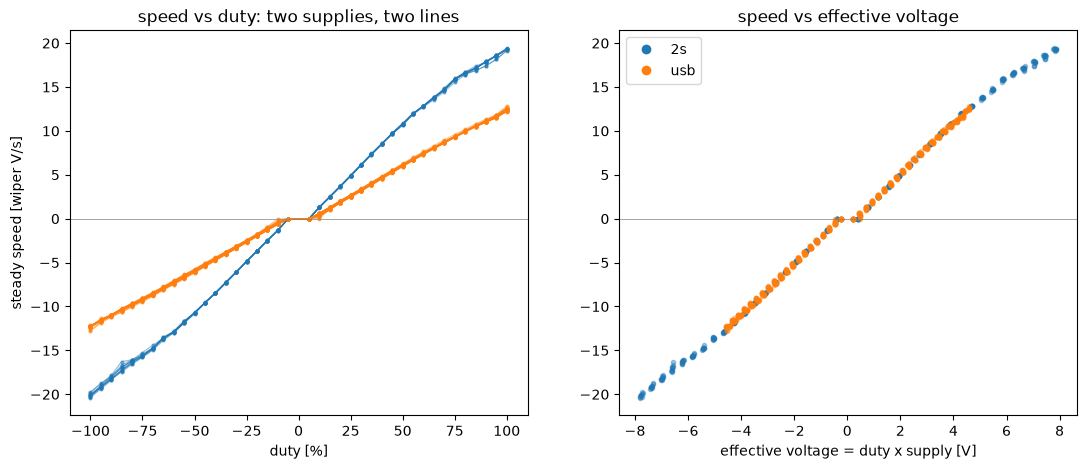

,2s slope_Vps_per_V,2s intercept_Vps,usb slope_Vps_per_V,usb intercept_Vps,usb_minus_2s_pct
per-step supply,2.626,-0.062,2.685,0.030,2.255
single supply per series,2.628,-0.017,2.668,0.053,1.528


In [12]:
def step_speeds(df, sup_tab):
    sup = sup_tab.set_index("duty_pct")["supply_V"]
    sup_lo = sup[np.abs(sup.index) <= 30].mean()
    out = []
    for seg_id, seg in df.groupby("seg"):
        if seg_id == 0:
            continue
        n = len(seg)
        tail = seg.iloc[int(n * 0.4):]
        t = (tail["tick"] - tail["tick"].iloc[0]) / board.tick_hz
        slope = np.polyfit(t, tail["pos"] * board.v_adc_per_count, 1)[0]
        d = seg["duty_pct"].iloc[0]
        out.append({
            "duty_pct": d,
            "speed_Vps": slope,                       # wiper volts per second
            "supply_V": sup.get(d, sup_lo),
            "supply_mean_V": sup.mean(),
        })
    return pd.DataFrame(out)

SPEEDS = {label: {name: step_speeds(df, SUPPLY[label][name])
                  for name, (df, _) in recs.items()}
          for label, recs in SERIES}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for label, recs in SERIES:
    for name in recs:
        sp = SPEEDS[label][name].sort_values("duty_pct")
        axes[0].plot(sp["duty_pct"], sp["speed_Vps"], "-o", ms=2, lw=0.8,
                     alpha=0.5, color=COLORS[label])
        veff = sp["duty_pct"] / 100.0 * sp["supply_V"]
        axes[1].plot(veff, sp["speed_Vps"], "o", ms=3, alpha=0.4, color=COLORS[label])
    axes[1].plot([], [], "o", color=COLORS[label], label=label)
axes[0].set_xlabel("duty [%]")
axes[0].set_ylabel("steady speed [wiper V/s]")
axes[0].set_title("speed vs duty: two supplies, two lines")
axes[1].set_xlabel("effective voltage = duty x supply [V]")
axes[1].set_title("speed vs effective voltage")
axes[1].legend()
for ax in axes:
    ax.axhline(0, color="grey", lw=0.5)
plt.show()

fits = {}
for label, recs in SERIES:
    pts = pd.concat(SPEEDS[label].values())
    for kind, col in [("per-step supply", "supply_V"),
                      ("single supply per series", "supply_mean_V")]:
        veff = pts["duty_pct"] / 100.0 * pts[col]
        m = veff.abs() > 1.0     # fit above 1 V, clear of the motion threshold
        k = np.polyfit(veff[m], pts["speed_Vps"][m], 1)
        fits.setdefault(kind, {})[f"{label} slope_Vps_per_V"] = k[0]
        fits[kind][f"{label} intercept_Vps"] = k[1]
fits = pd.DataFrame(fits).T
fits["usb_minus_2s_pct"] = (
    (fits["usb slope_Vps_per_V"] - fits["2s slope_Vps_per_V"])
    / fits["2s slope_Vps_per_V"] * 100)
fits.round(3)

Findings:

- **The number.** On the 2S campaign the steady speed rises at 2.626 wiper
  V/s per volt of effective voltage, with an intercept of -0.06 wiper V/s.
  That is the speed-voltage constant this notebook hands on. It is fitted
  on a rail that moves by 0.3% across the whole duty range, so nothing in
  it is rail droop wearing a duty costume.
- Against duty (left panel), the two campaigns separate. The 2S line is
  straight and steeper by roughly the ratio of the supply voltages, and the
  USB curve bends as its rail sags, so duty alone does not predict speed.
- Against effective voltage (right panel), the two campaigns come close to
  one line. The USB slope is 2.685, 2.2% above the 2S one. The linear
  speed-voltage relationship of the brushed DC motor model therefore holds
  across a 4.6 V and a 7.8 V rail to about two percent, with no calibration
  involved. That is the cross-check, and it passes.
- The per-step supply correction is no longer worth anything, and this is
  a change from the earlier version of this notebook. With one supply value
  per campaign the two slopes differ by 1.5%; with the per-step value they
  differ by 2.2%. The per-step correction moves the 2S slope by 0.1% and
  the USB slope by 0.6%, and it moves USB the wrong way. *Hypothesis (not
  tested here): the p90 of the driven terminal overstates the average
  voltage the USB supply delivered within a step, since the USB rail swings
  far more within a step than the 2S pack does, and the p90 is by
  construction near the top of that swing. Testing it needs a per-sample
  effective voltage in place of the per-step p90, which needs the
  bridge-state gating of notebook 01.*

### 6.4 Repeatability across captures

Each campaign is a run of identical captures separated by reboots and
cooldowns, so drift across captures reflects the hardware. The figure
shows the steady speed of the +100% duty step for every capture, in order.

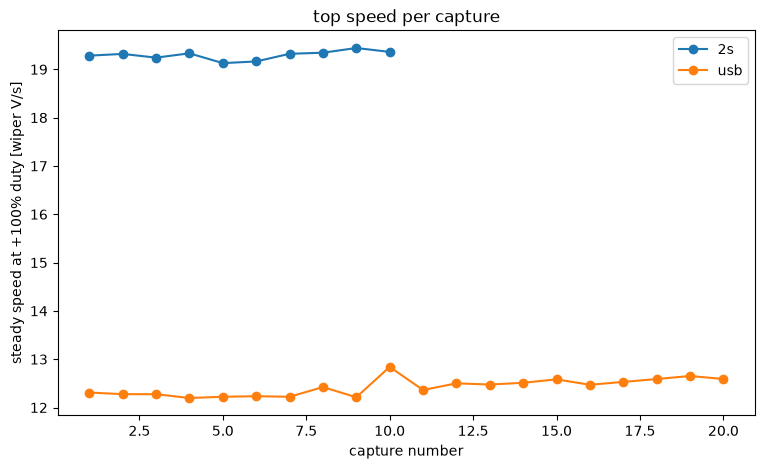

,captures,mean_Vps,first_Vps,last_Vps,spread_pct
series,,,,,
2s,10,19.293,19.283,19.361,1.623
usb,20,12.424,12.310,12.590,5.183


In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
rows = []
for label, recs in SERIES:
    xs, ys = [], []
    for name in recs:
        n = int(name.split("-")[1])
        sp = SPEEDS[label][name]
        row = sp[np.isclose(sp["duty_pct"], 100.0, atol=0.1)]
        xs.append(n)
        ys.append(row["speed_Vps"].iloc[0])
    order = np.argsort(xs)
    xs, ys = np.array(xs)[order], np.array(ys)[order]
    ax.plot(xs, ys, "-o", color=COLORS[label], label=label)
    rows.append({"series": label,
                 "captures": len(ys),
                 "mean_Vps": np.mean(ys),
                 "first_Vps": ys[0],
                 "last_Vps": ys[-1],
                 "spread_pct": (max(ys) - min(ys)) / np.mean(ys) * 100})
ax.set_xlabel("capture number")
ax.set_ylabel("steady speed at +100% duty [wiper V/s]")
ax.set_title("top speed per capture")
ax.legend()
plt.show()
pd.DataFrame(rows).set_index("series").round(3)

The 2S captures agree within 1.6% at full duty across ten captures, with
no trend: 19.28 wiper V/s in the first and 19.36 in the last, against a
mean of 19.29. The USB captures scatter 5.2% across twenty, three times
wider, and the full-duty rail moved by only a few millivolts over the same
run, so the rail level does not explain it. Plausible contributors include
thermal state of the gear train and the motor, and the fact that a USB
full-duty step sits much closer to the motion threshold in torque terms.
Neither is isolated here. Any single capture carries a few percent of
unexplained variation, so fits in later notebooks pool across captures,
and the 2S campaign is the one to pool.

## 7. Limitations and open issues

- **One unit.** All numbers describe this one servo and this one board.
  The gear train has prior wear.
- **The board is a hacked rig.** Section 1 describes it, and its registry
  entry says so in the table of section 2. The bus telemetry stream
  couples into the current amplifier output on this board. It is flat
  within about a count at rest on this firmware build (section 5.2), but
  it is a limitation of the board, and I leave it as one. The next board
  revision does not have it, and nothing in this notebook is written to
  dodge it.
- **Voltages are nominal-referenced.** All voltages scale with the true
  VDD of this unit, which was not measured (section 2). The terminal bias
  is measured per capture and per terminal, but the divider ratio it
  enters with is a design value.
- **Angles are not.** The servo entry's pot scale is disputed by 9%
  between an eyeballed three-point fit and the ripple tach (both print in
  section 2 with their brackets), so this notebook reports position in
  wiper volts and never in degrees.
- **Position linearity is not established.** The pot's voltage-vs-angle
  linearity is not measured here. Nothing in this notebook depends on it.
  Fits that combine distant regions of travel will have to address it.
- **The windows are sized, not fixed.** Every rung travels about the same
  distance, so the net-travel panel of section 6.1 is flat by
  construction above the threshold and says nothing about speed there.
  Speed comes from the slope inside the window (section 6.3), not from
  the travel.
- **The sampling floors are this board's**, and the registry still marks
  them unverified against the flashed firmware. Section 5.4 shows the data
  is consistent with the 160-tick voltage floor and rules out 120, which
  is not the same as reading the build.
- **Supply sense and NTC are not streamed.** The six-field wire budget
  left `vbus_raw` and `ntc_raw` out, so the rail is inferred from the
  driven terminal (section 6.2) and temperature is unobserved. The
  once-per-capture `vbus_counts` in the metadata does not currently agree
  with the terminal (section 9).
- **The two campaigns are different sessions.** The current offset differs
  between them by 5.6 counts (section 5.2), so nothing here pools baseline
  constants across supplies.
- **2S exceeds the servo's usual rating.** The full-duty 2S steps apply
  about 7.8 V to a mechanism usually rated 4.8 to 6 V.

## 8. Next notebooks

The same measurement chain supports the next derivations, each one
checked against the firmware's on-servo computation:

- Notebook 01 establishes what each of the four bridge states does to the
  terminals, the shunt and the motion, and gates every later sample on
  the bridge state.
- Notebook 03 derives the back-EMF constant, notebook 04 the friction,
  including the motion threshold measured here, and notebook 05 the
  inertia.
- The firmware's supply estimator and current-offset handling, re-derived
  from this raw data and compared against the servo's live values.

## 9. Open discrepancies

Each entry is something this notebook measured that does not add up, the
candidate causes, and the one experiment that would tell those causes
apart. Nothing here is resolved by more analysis of these captures.

**9.1 The supply-sense channel reads 18% below the motor rail.**
Through `board.vsys_v` the metadata's rest reading is 6.38 V on 2S and
3.81 V on USB, against 7.77 V and 4.63 V at the driven terminal (section
6.2). The sign is impossible: the terminal is fed from the rail through
the high-side switch. Candidates: (a) the rail tap on this bodged board is
not the 15k/10k the board entry declares - multiplying the same counts by
the *terminal* divider ratio instead reproduces both terminal readings to
better than half a percent, which is what a bodge that reused the terminal
divider parts would look like; (b) the capture tool writes a pre-scaled
value into `vbus_counts` rather than raw counts; (c) a real drop between
the sensed node and the bridge, which (a) and the sign both argue against.
**Experiment that separates them:** with the board unpowered, measure the
two VSNS divider legs with an ohmmeter; then feed VSYS from a bench supply
at two known voltages and log `vbus_counts` at each. Case (a) shows the
declared legs to be wrong and a straight line through the origin with the
terminal ratio; case (b) shows the correct legs and a scale factor in the
tool; case (c) shows the correct legs and a load-dependent offset.

**9.2 The USB rail droop measured here is shallower than the registry's.**
The driven-terminal p90 gives -2.5% over 20% to 100% duty; the registry's
`rail_droop_usb_measured` is -3.5% [-4.0, -3.0] from the same campaign.
Candidates: (a) the p90 statistic, which sits near the top of the
within-step swing, hides part of the droop, and the registry used a
different statistic; (b) the registry number was taken over a different
capture subset (the USB grid holds twenty captures and the 2S grid ten);
(c) the high-side switch drop, which grows with current, partly cancels
the droop in a terminal-derived estimate. **Experiment that separates
them:** recompute the droop from the same captures with the mean, the
median and the p90 in turn, and separately with the low-side terminal
subtracted, and see which choice lands inside the registry bracket. This
is a method question, answerable from the captures already in hand, and it
belongs to whoever owns the registry entry.

**9.3 The two terminal taps read 4 counts apart at rest.**
`vmotor_a` reads 778 and `vmotor_b` 782 in every capture of both campaigns
(section 5.3), where the winding ties them together and they should read
the same. Candidates: (a) a real potential difference from bridge leakage
through the dividers; (b) residual ADC settling, since the two channels
sit in adjacent scan slots and `vmotor_a` follows the shunt channel, whose
source impedance is different. The earlier 48 MHz ADC configuration showed
an 18-count split in the same place, and moving to 24 MHz cut it to 4,
which points hard at (b). **Experiment that separates them:** swap the two
terminals' scan slots in the firmware's channel order and recapture the
baseline. Under (a) the split follows the terminal; under (b) it follows
the slot.

**9.4 Some USB 10% steps do not break away at all.**
Over forty USB 10% steps the mean aligned travel is 699 mV but the minimum
is exactly zero, while every 2S 10% step moves (section 6.1). Candidates:
(a) the applied voltage sits right on the friction threshold, so whether a
step breaks away depends on where the mechanism happens to be resting;
(b) stiction that depends on how long the mechanism sat still, which the
per-rung rest time and the preceding rung both affect; (c) rail droop
during the step pulling the applied voltage below the threshold after the
step starts. **Experiment that separates them:** the `breakaway`
experiment, which already exists in both datasets, ramps duty until motion
starts. Running it from several rest positions and after several dwell
times separates a fixed threshold (a) from a dwell-dependent one (b);
logging the terminal through the ramp separates (c), which would show the
rail crossing back down through the threshold.

**9.5 The per-step supply correction makes the two-supply agreement
worse.** With one supply value per campaign the slopes differ by 1.5%,
with the per-step value by 2.2% (section 6.3). Candidates: (a) the p90 is
a biased estimate of the average voltage inside a step, badly so on USB
where the rail swings within the step; (b) the substitution used for steps
below the voltage floor, which takes the mean of the gentlest measurable
steps, is wrong in a way that correlates with duty; (c) the high-side
switch drop grows with current, so the terminal-derived supply is
duty-dependent in a way the rail is not. **Experiment that separates
them:** gate the terminal samples by bridge state per sample (notebook 01)
and form a per-sample effective voltage, then refit. Under (a) the USB
slope moves toward 2S and the 2S slope barely moves; under (c) both slopes
move by the same fraction, since the switch drop is on both.

**9.6 USB full-duty speed scatters three times wider than 2S.**
1.6% across ten 2S captures against 5.2% across twenty USB ones (section
6.4), with a flat rail in both cases. Candidates: (a) thermal state, which
the cooldown between captures is supposed to control but which the longer
USB windows load differently; (b) proximity to the friction threshold, so
that friction variation is a larger fraction of the net torque at the
lower rail; (c) simply more captures, so a wider observed range from the
same underlying spread. **Experiment that separates them:** interleave
2S and USB captures within one session and compare the spread of each,
which removes the session and the ordering; (c) is settled first by
recomputing the 2S spread from bootstrapped subsets of twenty draws.